# SRP v4 — Step 4a: How Many Weak Learners? (Optuna, California Housing)

Every result so far used **K = 16** weak learners, a number nobody chose on evidence. This notebook finds out
what K should be, and whether the answer changes the step-3 conclusions.

### Design

| Part | What it does | Why |
|---|---|---|
| **Two Optuna studies** (40 trials each) | Mean-pool and causal attention, each searching K from 2 to 64 **jointly** with the settings K interacts with (expert width, features per expert, dropout, learning rate, ...) | The best K depends on how big each expert is. Tuning K alone would just return the best K *for the step-3 defaults*. |
| **Tuned XGBoost** (40 trials) | Same Optuna budget as each neural study | Neither side gets more search effort (the V2 notebook tuned only the neural side). |
| **Final evaluation** (5 seeds) | Best configs vs step-3 defaults vs tuned XGBoost, on the **test set** | Optuna scores each trial with a single seed and the validation set, so the winner may partly be luck. Five fresh seeds show whether it holds. |
| **K sweep** (3 seeds) | Each arm's best config with K = 2, 4, 8, 16, 32, 64 | The headline answer. Optuna's best trial is a single noisy draw; the sweep shows the whole K curve and whether it has a real peak or a plateau. |

### Rules
* Optuna only ever sees **validation** loss (of the final prediction). The test set is used once, in section 5.
* Trials use a shorter budget (≤150 epochs, patience 15) and a **MedianPruner** that stops trials clearly worse
  than the median at the same epoch. Final evaluation uses the standard protocol (≤200 epochs, patience 20).
* Experts run in batched mode (`batched=True`): the same function as the loop, about 2× faster.

## 0. Setup

In [1]:
import os, sys, time, json, warnings
warnings.filterwarnings("ignore")
PROJECT_DIR = os.getcwd()
sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

import numpy as np, pandas as pd, torch, optuna
import matplotlib.pyplot as plt, seaborn as sns
from joblib import Parallel, delayed

from datasets import make_task
from tuning import (NN_ARMS, STEP3_DEFAULTS, create_study, load_study, optuna_worker,
                    run_config, tune_xgb, make_xgb, xgb_metrics)

N_TRIALS        = 40              # per neural study; XGBoost gets the same
THREADS_PER_JOB = 2
N_JOBS          = max(1, min(8, (os.cpu_count() or 2) // THREADS_PER_JOB))
FINAL_SEEDS     = (0, 1, 2, 3, 4)
SWEEP_SEEDS     = (0, 1, 2)
K_GRID          = (2, 4, 8, 16, 32, 64)

RUN_DIR = os.path.join(PROJECT_DIR, "runs"); os.makedirs(RUN_DIR, exist_ok=True)
STUDY_PATH = os.path.join(RUN_DIR, "optuna_housing.journal")
LOG_PATH = os.path.join(RUN_DIR, "03_progress.log")
FRESH_STUDY = True                # delete any previous journal so the trial count is exact
if FRESH_STUDY:
    for p in (STUDY_PATH, LOG_PATH):
        if os.path.exists(p): os.remove(p)

def log(msg):
    print(msg, flush=True)
    with open(LOG_PATH, "a") as f: f.write(time.strftime("%H:%M:%S ") + msg + "\n")

def show(df, fmt=None, style=None):
    try:
        s = df.style.format(fmt or {}, na_rep="—"); display(style(s) if style else s)
    except (AttributeError, ImportError):
        display(df.round(4))

LABEL = {"meanpool": "Mean-pool", "causal": "Causal attn", "xgb": "XGBoost"}
COLOR = {"meanpool": "#7b5cff", "causal": "#e0527a", "xgb": "#ff8a3d"}
sns.set_theme(style="whitegrid", context="notebook")
optuna.logging.set_verbosity(optuna.logging.WARNING)
log(f"optuna {optuna.__version__} | torch {torch.__version__} | {N_JOBS} workers x {THREADS_PER_JOB} threads")

optuna 5.0.0 | torch 2.11.0+cu130 | 8 workers x 2 threads


## 1. Data — the same California Housing split as every previous notebook

In [2]:
task = make_task("california")
ARRAYS = task.arrays()
VAR_VA, VAR_TE = float(np.var(ARRAYS["yva"])), float(np.var(ARRAYS["yte"]))
val_r2 = lambda mse: 1.0 - mse / VAR_VA         # Optuna minimises val MSE; we report val R²
print(task.summary())

california  regression features=  8 train=12,384 val=4,128 test=4,128


## 2. The neural studies

Each study runs on all workers at once, sharing one journal file. Expect the causal study to take much longer:
attention runs are ~3× slower, and large K makes them slower still.

In [3]:
STUDY_TIME = {}
for arm in NN_ARMS:
    name = f"housing_{arm}"
    create_study(name, STUDY_PATH)
    per_worker = int(np.ceil(N_TRIALS / N_JOBS))
    log(f"[{arm}] {N_JOBS} workers x {per_worker} trials ...")
    t0 = time.time()
    Parallel(n_jobs=N_JOBS)(
        delayed(optuna_worker)(arm, name, STUDY_PATH, per_worker, 100 + w, ARRAYS,
                               threads=THREADS_PER_JOB, project_dir=PROJECT_DIR)
        for w in range(N_JOBS))
    STUDY_TIME[arm] = time.time() - t0
    st = load_study(name, STUDY_PATH)
    states = pd.Series([t.state.name for t in st.trials]).value_counts().to_dict()
    log(f"[{arm}] done in {STUDY_TIME[arm]/60:.1f} min | {states} | best val R² {val_r2(st.best_value):.4f} "
        f"| best K {st.best_params['num_learners']}")
STUDIES = {arm: load_study(f"housing_{arm}", STUDY_PATH) for arm in NN_ARMS}

[meanpool] 8 workers x 5 trials ...


[meanpool] done in 7.0 min | {'PRUNED': 22, 'COMPLETE': 18} | best val R² 0.8258 | best K 21


[causal] 8 workers x 5 trials ...


[causal] done in 30.8 min | {'COMPLETE': 25, 'PRUNED': 15} | best val R² 0.8303 | best K 3


## 3. XGBoost — the same Optuna budget

In [4]:
t0 = time.time()
xgb_study = tune_xgb(ARRAYS, "regression", n_trials=N_TRIALS, seed=0)
log(f"[xgb] {N_TRIALS} trials in {(time.time()-t0)/60:.1f} min | best val R² {xgb_study.best_value:.4f}")

[xgb] 40 trials in 0.8 min | best val R² 0.8533


## 4. What the studies found

In [5]:
rows = []
for arm, st in STUDIES.items():
    done = [t for t in st.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned = [t for t in st.trials if t.state == optuna.trial.TrialState.PRUNED]
    b = st.best_trial
    rows.append({"study": LABEL[arm], "trials": len(st.trials), "completed": len(done),
                 "pruned": len(pruned), "best val R²": val_r2(b.value),
                 "best K": b.params["num_learners"], "best params": b.user_attrs.get("n_params"),
                 "minutes": STUDY_TIME[arm] / 60})
rows.append({"study": "XGBoost", "trials": len(xgb_study.trials), "completed": len(xgb_study.trials),
             "pruned": 0, "best val R²": xgb_study.best_value, "best K": np.nan,
             "best params": np.nan, "minutes": np.nan})
show(pd.DataFrame(rows).set_index("study"),
     {"best val R²": "{:.4f}", "minutes": "{:.1f}", "best K": "{:.0f}", "best params": "{:,.0f}"})

best = pd.DataFrame({LABEL[a]: pd.Series(STUDIES[a].best_params) for a in NN_ARMS})
best["step-3 default (causal)"] = pd.Series(STEP3_DEFAULTS["causal"])
best["step-3 default (mean-pool)"] = pd.Series(STEP3_DEFAULTS["meanpool"])
print("Best configuration per study, next to the step-3 defaults:")
display(best)
print("\nBest XGBoost configuration:", {k: (round(v, 4) if isinstance(v, float) else v)
                                      for k, v in xgb_study.best_params.items()})

,trials,completed,pruned,best val R²,best K,best params,minutes
study,,,,,,,
Mean-pool,40,18,22,0.8258,21.0,43647.0,6.9696
Causal attn,40,25,15,0.8303,3.0,9057.0,30.7519
XGBoost,40,40,0,0.8533,NaN,NaN,NaN


Best configuration per study, next to the step-3 defaults:


,Mean-pool,Causal attn,step-3 default (causal),step-3 default (mean-pool)
attn_depth,NaN,2.000000,2.0000,NaN
depth,2.000000,1.000000,1.0000,1.0000
dropout,0.271031,0.062903,0.1000,0.1000
embed_dim,64.000000,16.000000,32.0000,32.0000
feature_frac,0.404083,0.448344,0.7000,0.7000
head_depth,1.000000,NaN,NaN,2.0000
head_hidden,107.000000,NaN,NaN,148.0000
hidden_dim,19.000000,32.000000,16.0000,16.0000
lr,0.001486,0.001461,0.0010,0.0010
num_heads,NaN,2.000000,4.0000,NaN



Best XGBoost configuration: {'n_estimators': 732, 'max_depth': 11, 'learning_rate': 0.0198, 'subsample': 0.5439, 'colsample_bytree': 0.6342, 'min_child_weight': 10.4071, 'reg_lambda': 0.4929, 'reg_alpha': 0.0006}


### 4.1 Search progress, and every trial's K

Left: best validation R² found so far. Right: every completed trial's K against its validation R².
The right-hand plot is the **raw evidence about K**. A clear ridge means K matters; a flat cloud means other
settings matter more.

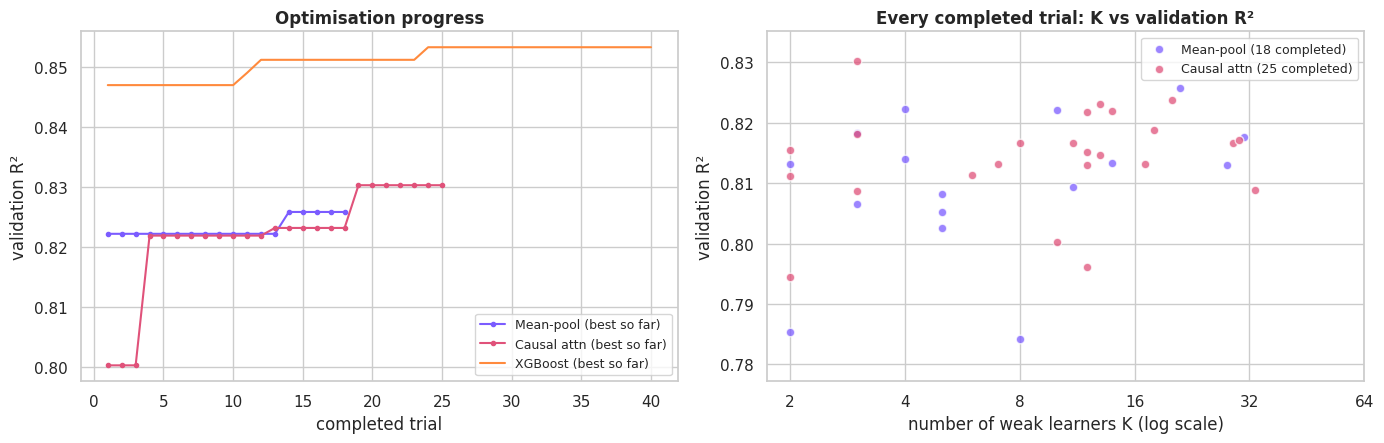

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for arm, st in STUDIES.items():
    done = [t for t in st.trials if t.state == optuna.trial.TrialState.COMPLETE]
    done.sort(key=lambda t: t.number)
    r2 = np.array([val_r2(t.value) for t in done])
    axes[0].plot(np.arange(1, len(r2) + 1), np.maximum.accumulate(r2), "-o", ms=3,
                 color=COLOR[arm], label=f"{LABEL[arm]} (best so far)")
    axes[1].scatter([t.params["num_learners"] for t in done], r2, s=38, alpha=.75,
                    color=COLOR[arm], edgecolor="white", label=f"{LABEL[arm]} ({len(done)} completed)")
xr2 = np.maximum.accumulate([t.value for t in xgb_study.trials])
axes[0].plot(np.arange(1, len(xr2) + 1), xr2, "-", color=COLOR["xgb"], label="XGBoost (best so far)")
axes[0].set_xlabel("completed trial"); axes[0].set_ylabel("validation R²")
axes[0].set_title("Optimisation progress", fontweight="bold"); axes[0].legend(fontsize=9)
axes[1].set_xscale("log", base=2); axes[1].set_xticks(K_GRID); axes[1].set_xticklabels(K_GRID)
axes[1].set_xlabel("number of weak learners K (log scale)"); axes[1].set_ylabel("validation R²")
lo = np.percentile([val_r2(t.value) for st in STUDIES.values() for t in st.trials
                    if t.state == optuna.trial.TrialState.COMPLETE], 10)
axes[1].set_ylim(lo - 0.01, None)
axes[1].set_title("Every completed trial: K vs validation R²", fontweight="bold"); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### 4.2 Which settings actually matter?

Optuna's fANOVA importance estimates how much of the variation in validation loss each hyperparameter
explains. If `num_learners` ranks low, the answer to "how many weak learners?" is "it barely matters".

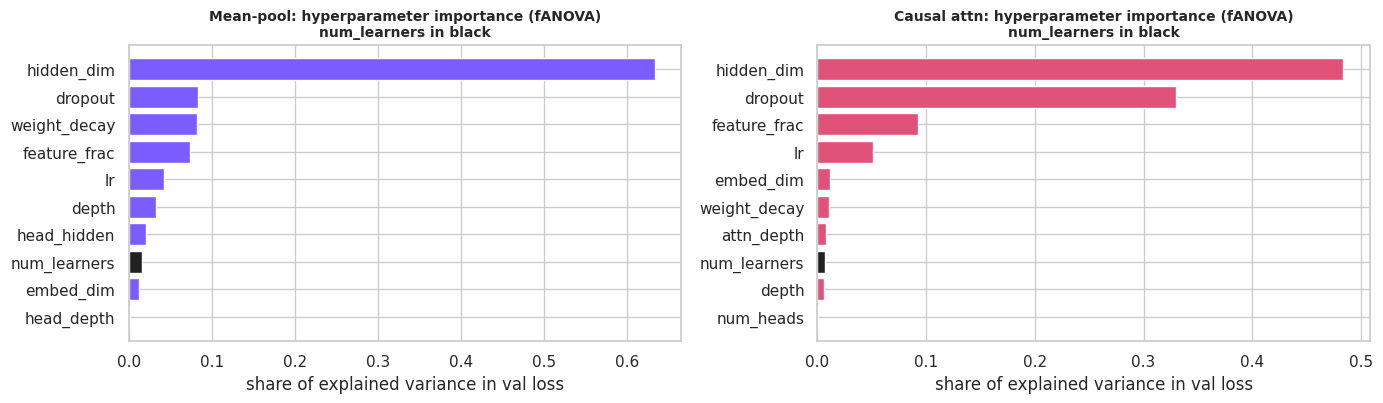

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
IMPORTANCE = {}
for ax, (arm, st) in zip(axes, STUDIES.items()):
    imp = optuna.importance.get_param_importances(st, evaluator=optuna.importance.FanovaImportanceEvaluator(seed=0))
    IMPORTANCE[arm] = imp
    names, vals = list(imp.keys())[::-1], list(imp.values())[::-1]
    ax.barh(names, vals, color=[("#222" if n == "num_learners" else COLOR[arm]) for n in names])
    ax.set_title(f"{LABEL[arm]}: hyperparameter importance (fANOVA)\nnum_learners in black",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("share of explained variance in val loss")
plt.tight_layout(); plt.show()

## 5. Final evaluation — best configs on 5 fresh seeds, on the test set

The step-3 defaults are re-run here too, under the same batched implementation, so "tuned vs default" is an
apples-to-apples comparison (and a check that batching reproduces step 3's numbers).

In [8]:
CONFIGS = {("meanpool", "tuned"): STUDIES["meanpool"].best_params,
           ("causal",   "tuned"): STUDIES["causal"].best_params,
           ("meanpool", "step-3 default"): STEP3_DEFAULTS["meanpool"],
           ("causal",   "step-3 default"): STEP3_DEFAULTS["causal"]}

def run_many(specs):
    t0 = time.time(); out = []
    for r in Parallel(n_jobs=N_JOBS, return_as="generator")(
            delayed(run_config)(arm, params, ARRAYS, seed, threads=THREADS_PER_JOB) for arm, params, seed, _ in specs):
        out.append(r)
    return out, time.time() - t0

specs = [(arm, p, s, variant) for (arm, variant), p in CONFIGS.items() for s in FINAL_SEEDS]
results, secs = run_many(specs)
for r, (_, _, _, variant) in zip(results, specs):
    r["variant"] = variant
log(f"[final] {len(specs)} runs in {secs/60:.1f} min")

xgb_rows = []
for s in FINAL_SEEDS:
    m = make_xgb(xgb_study.best_params, "regression", seed=s).fit(ARRAYS["Xtr"], ARRAYS["ytr"])
    te = xgb_metrics(m, ARRAYS["Xte"], ARRAYS["yte"], "regression")
    xgb_rows.append({"arm": "xgb", "variant": "tuned", "seed": s, "K": np.nan, "n_params": np.nan,
                     **{f"test_{k}": v for k, v in te.items()}})
FINAL = pd.DataFrame(results + xgb_rows)

g = FINAL.groupby(["arm", "variant"])
final_table = pd.DataFrame({"K": g["K"].first(), "Params": g["n_params"].first(),
                            "Test R²": g["test_r2"].mean(), "± std": g["test_r2"].std(),
                            "Test RMSE": g["test_rmse"].mean(), "Test MAE": g["test_mae"].mean()})
final_table.index = [f"{LABEL[a]} — {v}" for a, v in final_table.index]
final_table = final_table.sort_values("Test R²", ascending=False)
show(final_table, {"K": "{:.0f}", "Params": "{:,.0f}", "Test R²": "{:.4f}", "± std": "{:.4f}",
                   "Test RMSE": "{:.4f}", "Test MAE": "{:.4f}"},
     style=lambda s: s.background_gradient(subset=["Test R²"], cmap="Purples"))

[final] 20 runs in 12.8 min


,K,Params,Test R²,± std,Test RMSE,Test MAE
XGBoost — tuned,NaN,NaN,0.8508,0.0019,0.4421,0.2893
Mean-pool — tuned,21.0,43647.0,0.8187,0.0014,0.4874,0.3253
Causal attn — tuned,3.0,9057.0,0.8172,0.0061,0.4894,0.3240
Mean-pool — step-3 default,16.0,37645.0,0.8104,0.0050,0.4984,0.3321
Causal attn — step-3 default,16.0,37697.0,0.8074,0.0055,0.5024,0.3331


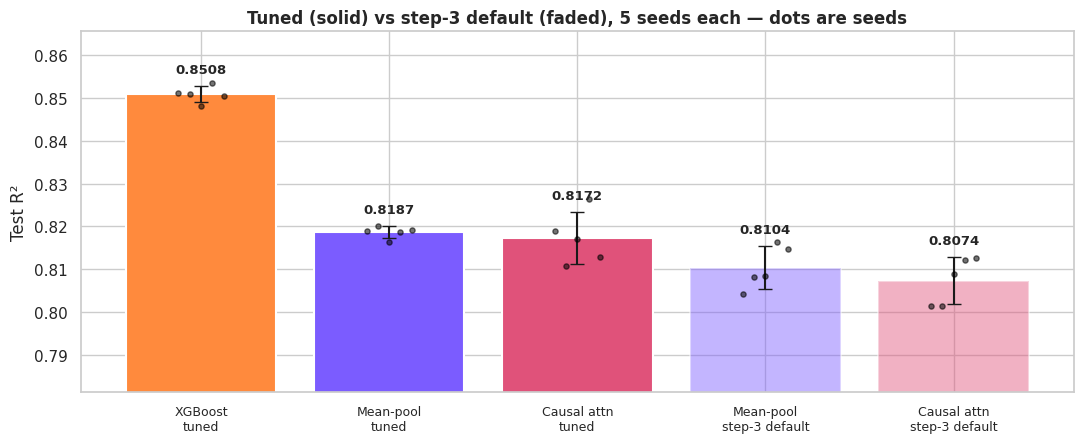

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.6))
order = list(final_table.index)
col = lambda name: COLOR["xgb"] if name.startswith("XGBoost") else COLOR["causal"] if name.startswith("Causal") else COLOR["meanpool"]
key = {f"{LABEL[a]} — {v}": (a, v) for a, v in g.groups.keys()}
for i, name in enumerate(order):
    a, v = key[name]
    ys = FINAL[(FINAL.arm == a) & (FINAL.variant == v)]["test_r2"].values
    ax.bar(i, ys.mean(), yerr=ys.std(ddof=1), capsize=5, color=col(name),
           alpha=(1.0 if v == "tuned" else 0.45), edgecolor="white", linewidth=1.5)
    ax.scatter(np.full(len(ys), i) + np.linspace(-.12, .12, len(ys)), ys, s=14, color="black", alpha=.55, zorder=3)
    ax.text(i, ys.mean() + ys.std(ddof=1) + 0.003, f"{ys.mean():.4f}", ha="center", fontweight="bold", fontsize=9.5)
ax.set_xticks(range(len(order))); ax.set_xticklabels([n.replace(" — ", "\n") for n in order], fontsize=9)
ax.set_ylabel("Test R²"); ymin = FINAL["test_r2"].min()
ax.set_ylim(ymin - 0.02, FINAL["test_r2"].max() + 0.012)
ax.set_title("Tuned (solid) vs step-3 default (faded), 5 seeds each — dots are seeds", fontweight="bold")
plt.tight_layout(); plt.show()

## 6. The K sweep — the actual answer to "how many weak learners?"

Each arm's **tuned** configuration, with only K changed, trained on 3 seeds. K is chosen by **validation** R²
(left); the **test** R² (right) is shown for reference. If several K values sit within each other's seed
spread, the honest answer is a range, not a single number.

[sweep] 36 runs in 21.9 min


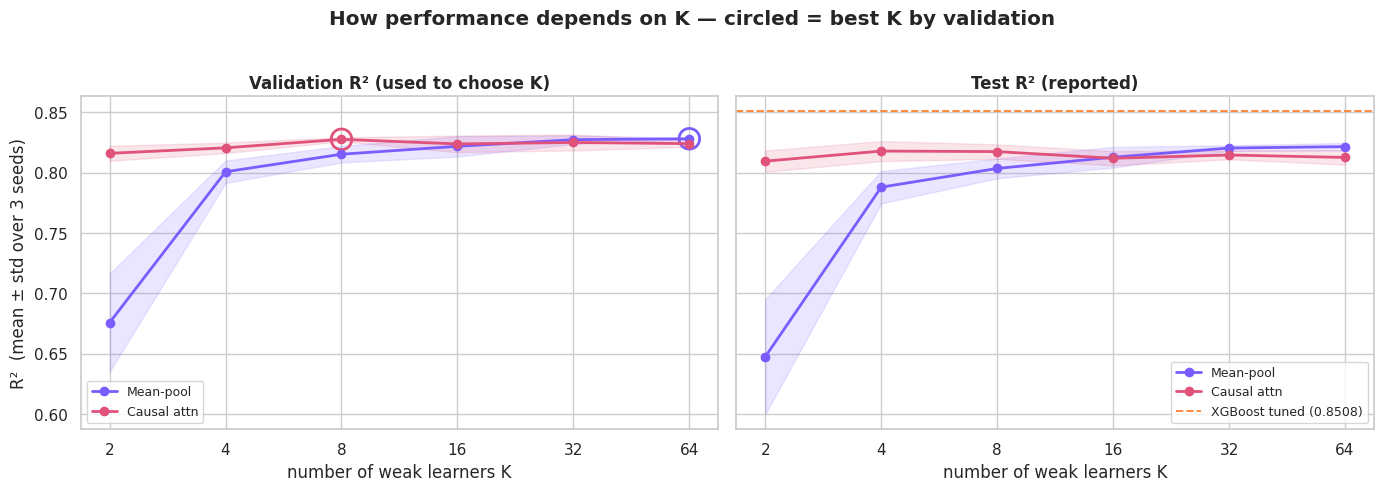

val_r2  val_sd  test_r2  test_sd  params  minutes
arm         K                                                    
Causal attn 2   0.8161  0.0062   0.8096   0.0088    8353   2.2357
            4   0.8207  0.0044   0.8180   0.0083    9761   2.6822
            8   0.8277  0.0017   0.8175   0.0060   12577   3.3973
            16  0.8239  0.0069   0.8120   0.0059   18209   4.1297
            32  0.8251  0.0066   0.8147   0.0036   29473   6.6300
            64  0.8242  0.0026   0.8127   0.0060   52001  13.2221
Mean-pool   2   0.6757  0.0407   0.6475   0.0476   10663   0.7033
            4   0.8008  0.0093   0.7881   0.0134   14135   1.2883
            8   0.8154  0.0068   0.8036   0.0082   21079   2.1232
            16  0.8219  0.0085   0.8129   0.0086   34967   3.3532
            32  0.8274  0.0036   0.8205   0.0023   62743   5.6122
            64  0.8282  0.0007   0.8217   0.0031  118295  12.2088

In [10]:
specs = [(arm, {**STUDIES[arm].best_params, "num_learners": k}, s, "sweep")
         for arm in NN_ARMS for k in K_GRID for s in SWEEP_SEEDS]
specs.sort(key=lambda sp: -(sp[1]["num_learners"] * (3 if sp[0] == "causal" else 1)))   # slowest first
sweep, secs = run_many(specs)
SWEEP = pd.DataFrame(sweep)
log(f"[sweep] {len(specs)} runs in {secs/60:.1f} min")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
xgb_test = FINAL[FINAL.arm == "xgb"]["test_r2"].mean()
for ax, metric, title in [(axes[0], "val_r2", "Validation R² (used to choose K)"),
                          (axes[1], "test_r2", "Test R² (reported)")]:
    for arm in NN_ARMS:
        s = SWEEP[SWEEP.arm == arm].groupby("K")[metric].agg(["mean", "std"]).reindex(K_GRID)
        ax.fill_between(K_GRID, s["mean"] - s["std"], s["mean"] + s["std"], color=COLOR[arm], alpha=.15)
        ax.plot(K_GRID, s["mean"], "-o", color=COLOR[arm], lw=2, label=LABEL[arm])
        kbest = int(s["mean"].idxmax()) if metric == "val_r2" else None
        if kbest:
            ax.scatter([kbest], [s.loc[kbest, "mean"]], s=220, facecolors="none", edgecolors=COLOR[arm], lw=2)
    if metric == "test_r2":
        ax.axhline(xgb_test, color=COLOR["xgb"], ls="--", lw=1.4, label=f"XGBoost tuned ({xgb_test:.4f})")
    ax.set_xscale("log", base=2); ax.set_xticks(K_GRID); ax.set_xticklabels(K_GRID)
    ax.set_xlabel("number of weak learners K"); ax.set_title(title, fontweight="bold"); ax.legend(fontsize=9)
axes[0].set_ylabel("R²  (mean ± std over 3 seeds)")
plt.suptitle("How performance depends on K — circled = best K by validation", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

sweep_table = SWEEP.groupby(["arm", "K"]).agg(val_r2=("val_r2", "mean"), val_sd=("val_r2", "std"),
                                              test_r2=("test_r2", "mean"), test_sd=("test_r2", "std"),
                                              params=("n_params", "first"), minutes=("seconds", lambda x: x.mean() / 60))
sweep_table.index = sweep_table.index.set_levels([LABEL[a] for a in sweep_table.index.levels[0]], level=0)
show(sweep_table, {"val_r2": "{:.4f}", "val_sd": "{:.4f}", "test_r2": "{:.4f}", "test_sd": "{:.4f}",
                   "params": "{:,.0f}", "minutes": "{:.1f}"})

## 7. Findings

*(Computed from the runs above.)*

In [11]:
sep = "=" * 92
print(sep); print("FINDINGS — how many weak learners? (California Housing)"); print(sep)

def fin(arm, variant):
    x = FINAL[(FINAL.arm == arm) & (FINAL.variant == variant)]["test_r2"]
    return x.mean(), x.std(ddof=1)

print("\nQ1. What K does each arm want?")
for arm in NN_ARMS:
    s = SWEEP[SWEEP.arm == arm].groupby("K")["val_r2"].agg(["mean", "std"])
    kbest = int(s["mean"].idxmax())
    band = s["mean"].max() - s.loc[kbest, "std"]
    plateau = [int(k) for k in s.index if s.loc[k, "mean"] >= band]
    rank = list(IMPORTANCE[arm].keys()).index("num_learners") + 1
    print(f"    {LABEL[arm]:12s} Optuna best trial K={STUDIES[arm].best_params['num_learners']:<3d}"
          f" | sweep best K={kbest:<3d} (val R² {s['mean'].max():.4f})"
          f" | K within one seed-std of the best: {plateau}"
          f" | K importance rank {rank}/{len(IMPORTANCE[arm])} ({IMPORTANCE[arm]['num_learners']:.1%})")
    if len(plateau) >= 3:
        print(f"    {'':12s} -> a broad plateau: K matters little inside {min(plateau)}-{max(plateau)}.")

print(f"\nQ2. Did tuning improve on the step-3 defaults? (test R², {len(FINAL_SEEDS)} seeds)")
for arm in NN_ARMS:
    (mt, st_), (md_, sd_) = fin(arm, "tuned"), fin(arm, "step-3 default")
    d = mt - md_
    noise = np.sqrt(st_**2 + sd_**2)
    verdict = "beyond seed noise" if abs(d) > noise else "within seed noise"
    print(f"    {LABEL[arm]:12s} default {md_:.4f} ± {sd_:.4f}  ->  tuned {mt:.4f} ± {st_:.4f}"
          f"   ({d:+.4f}, {verdict})")

xm, xs = FINAL[FINAL.arm == "xgb"]["test_r2"].mean(), FINAL[FINAL.arm == "xgb"]["test_r2"].std(ddof=1)
print(f"\nQ3. Tuned XGBoost (same {N_TRIALS}-trial budget): {xm:.4f} ± {xs:.4f}")
for arm in NN_ARMS:
    mt, _ = fin(arm, "tuned")
    print(f"    gap from tuned {LABEL[arm]:12s}: {mt - xm:+.4f}")

print("\nQ4. After tuning, does attention beat mean-pool?")
(mm, ms), (cm, cs) = fin("meanpool", "tuned"), fin("causal", "tuned")
noise = np.sqrt(ms**2 + cs**2)
print(f"    tuned causal − tuned mean-pool = {cm - mm:+.4f}  (seed noise ≈ {noise:.4f}) -> "
      + ("attention ahead" if cm - mm > noise else "mean-pool ahead" if mm - cm > noise else "not distinguishable"))
mp_params = FINAL[(FINAL.arm == "meanpool") & (FINAL.variant == "tuned")]["n_params"].iloc[0]
ca_params = FINAL[(FINAL.arm == "causal") & (FINAL.variant == "tuned")]["n_params"].iloc[0]
print(f"    (sizes: tuned mean-pool {mp_params:,.0f} params, tuned causal {ca_params:,.0f} params —"
      f" each arm chose its own size, so this is 'best vs best', not a capacity-matched test)")

print("\nQ5. Does attention's value depend on K?  (test R², sweep, causal − mean-pool at each K)")
diff = (SWEEP[SWEEP.arm == "causal"].groupby("K")["test_r2"].mean()
        - SWEEP[SWEEP.arm == "meanpool"].groupby("K")["test_r2"].mean())
print("    " + "   ".join(f"K={int(k)}: {v:+.4f}" for k, v in diff.items()))
print(sep)

FINDINGS — how many weak learners? (California Housing)

Q1. What K does each arm want?
    Mean-pool    Optuna best trial K=21  | sweep best K=64  (val R² 0.8282) | K within one seed-std of the best: [64] | K importance rank 8/10 (1.6%)
    Causal attn  Optuna best trial K=3   | sweep best K=8   (val R² 0.8277) | K within one seed-std of the best: [8] | K importance rank 8/10 (0.7%)

Q2. Did tuning improve on the step-3 defaults? (test R², 5 seeds)
    Mean-pool    default 0.8104 ± 0.0050  ->  tuned 0.8187 ± 0.0014   (+0.0083, beyond seed noise)
    Causal attn  default 0.8074 ± 0.0055  ->  tuned 0.8172 ± 0.0061   (+0.0099, beyond seed noise)

Q3. Tuned XGBoost (same 40-trial budget): 0.8508 ± 0.0019
    gap from tuned Mean-pool   : -0.0321
    gap from tuned Causal attn : -0.0336

Q4. After tuning, does attention beat mean-pool?
    tuned causal − tuned mean-pool = -0.0015  (seed noise ≈ 0.0062) -> not distinguishable
    (sizes: tuned mean-pool 43,647 params, tuned causal 9,057 para

## 8. Reading this against the project

* **The best K and the width of its plateau** tell you how much the core idea, many weak experts, depends on
  *having many* of them. A broad plateau from small K means a handful of experts already captures most of the benefit.
* **Tuned vs default** says how much of the step-3 gap to XGBoost was simply untuned hyperparameters.
* **Tuned XGBoost** is the bar with equal search effort. The gap that remains after tuning is the architectural gap.
* The next notebook (`04_grinsztajn_diagnostics`) asks *why* that gap exists, using Grinsztajn et al.'s three tests
  on Covertype, Poker Hand and HIGGS.